# Coding Exercises (Part 5)

Now, you will have the opportunity to practice what you have learned. <br>
__Follow the instructions__ and insert your code! 

The correct answer is provided below your coding cell. There you can check whether your code is correct.

If you need some help or if you want to check your code, you can also have a look at the __solutions__.

### Have Fun!

--------------------------------------------------------------------------------------------------------------

## Exercise 2: OLS Regression, ANOVA and Hypothesis Testing

In the following you are going to analyze the relationship between __budget and revenue__ for movies released between __Jan-01-2000__ and __Dec-31-2009__.

In [16]:
#run the cell!
import pandas as pd
pd.options.display.float_format = "{:,.2f}".format
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackened.figure_format ="svg"


In [17]:
#run the cell!
df = pd.read_csv("bud_vs_rev.csv", parse_dates = ["release_date"], index_col = "release_date")
df = df.loc["2000":"2009"]
df

,title,budget,revenue
release_date,,,
2000-01-12,Next Friday,11.00,59.83
2000-01-14,Supernova,90.00,14.83
2000-01-24,Saving Grace,10.00,26.33
2000-01-28,Isn't She Great,36.00,3.00
2000-02-01,The Broken Hearts Club: A Romantic Comedy,1.00,1.74
...,...,...,...
2009-12-23,Sherlock Holmes,90.00,524.03
2009-12-23,It's Complicated,85.00,219.10
2009-12-23,3 Idiots,9.00,70.00


In [23]:
df.describe(include="number")

,budget,revenue
count,"1,780.00","1,780.00"
mean,37.19,94.62
std,40.17,162.21
min,0.00,0.00
25%,9.00,9.98
50%,25.00,38.55
75%,50.00,108.65
max,300.00,"2,787.97"


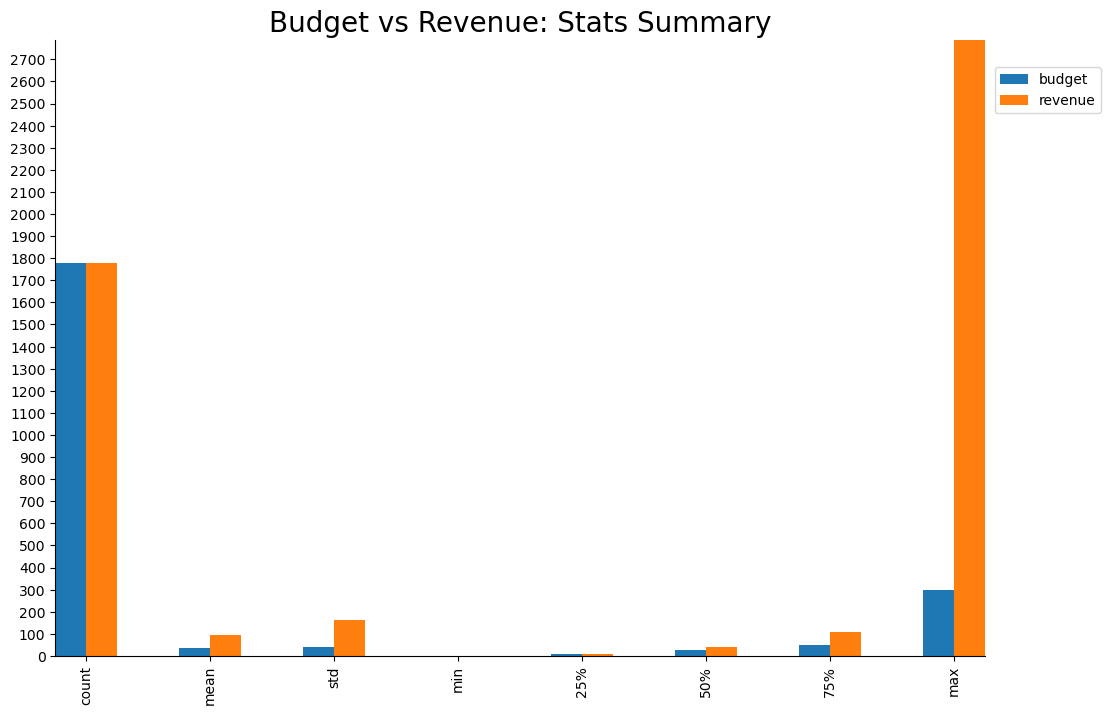

In [45]:
df.describe(include="number").plot.bar(figsize = (12, 8))
plt.title("Budget vs Revenue: Stats Summary", fontsize = 20)

plt.yticks(np.arange(0, 2800, 100))
ax = plt.gca()
ax.spines[["right", "top"]].set_visible(False)
ax.autoscale(enable = True , axis = "both" , tight = True)
plt.legend(bbox_to_anchor=(1.01, 0.956), loc='upper left', borderaxespad=0.)
plt.show()

1. Import __ols__ from statsmodels.formula.api

In [46]:
from statsmodels.formula.api import ols

2. Create an __Ordinary Least Squares Regression Model__ with the dependent variable __revenue__ and the independent variable __budget__.

In [47]:
model = ols("revenue~budget" , data = df)

3. __Fit__ the model.   

In [48]:
results = model.fit()

4. Get the __Regression Coefficients__.

In [49]:
results.params

Intercept   -12.19
budget        2.87
dtype: float64

In [52]:
results.pvalues

Intercept   0.00
budget      0.00
dtype: float64

In [53]:
results.tvalues

Intercept   -3.31
budget      42.64
dtype: float64

5. Print the __Summary Table__. Interpret __p-values__ of Regression Coefficients.

In [51]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.506
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     1818.
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          2.78e-274
Time:                        13:05:51   Log-Likelihood:                -10957.
No. Observations:                1780   AIC:                         2.192e+04
Df Residuals:                    1778   BIC:                         2.193e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -12.1949      3.686     -3.308      0.0

$H_{0}: \text{Intercept} = 0$ <br>
$H_{a}: \text{Intercept} \neq 0$

Since the p-values is 0.001 which is less than 1%, so the $H_{0}$ falls in the rejection area, hence we will have enough evidence to reject it and accept the alternative hypothesis which states that the intercept is not 0.

$H_{0}: \text{Slope} = 0$ <br>
$H_{a}: \text{Slope} \neq 0$

Since the p-values is 0.000 which is less than 1%, so the $H_{0}$ falls in the rejection area, hence we will have enough evidence to reject it and accept the alternative hypothesis which states that the Slope is not 0.

Perform an Analysis of Variance (__ANOVA__) and calculate the following:

6. __Total Variation__ (TSS)

In [57]:
tss = results.centered_tss
tss

np.float64(46812006.026643634)

7. __Explained Variation__ (RSS)

In [58]:
rss = results.mse_model
rss

np.float64(23669101.39365063)

8. __Unexplained Variation__ (SSE)

In [59]:
sse = results.ssr
sse

np.float64(23142904.632993005)

9. __Mean Squared Error__ (MSE)

In [60]:
mse = results.mse_resid
mse

np.float64(13016.256823955571)

10. Coefficient of Determination (__R squared__) -> two alternatives

In [61]:
#Alternative 1
results.rsquared

np.float64(0.5056203184323924)

In [63]:
#Alternative 2
r = np.corrcoef(df.budget, df.revenue)[0, 1]
r**2

np.float64(0.5056203184323927)

------------------------------------------------------------------------------------------

In the following you are going to create the Market Model (__Single Factor Model__) for __Walmart__ (WMT) using daily price data from  __Jan-01-2000__ until __Dec-31-2009__. Use the __SP500 Total Return Index__ ("^SP500TR") as Proxy for the __Market Portfolio__.

In [64]:
#run the cell!
import yfinance as yf
import datetime as dt
from statsmodels.formula.api import ols

In [73]:
today = dt.datetime.today().strftime("%Y-%m-%d")
#dt.datetime.today().date()
today

'2026-06-19'

In [74]:
past_date = "2009-12-31"
past_date

'2009-12-31'

In [75]:
#run the cell!
df = yf.download(["WMT", "^SP500TR"], start = "1999-12-31", end = "2009-12-31" , multi_level_index = False)
df = df["Close"]
df

[*********************100%***********************]  2 of 2 completed


Ticker,WMT,^SP500TR
Date,,
1999-12-31,14.64,"2,021.40"
2000-01-03,14.15,"2,002.11"
2000-01-04,13.62,"1,925.41"
2000-01-05,13.35,"1,929.28"
2000-01-06,13.49,"1,931.51"
...,...,...
2009-12-23,12.69,"1,845.80"
2009-12-24,12.76,"1,855.50"
2009-12-28,12.85,"1,857.89"


In [76]:
#run the cell!
ret = df.pct_change().dropna()
ret

Ticker,WMT,^SP500TR
Date,,
2000-01-03,-0.03,-0.01
2000-01-04,-0.04,-0.04
2000-01-05,-0.02,0.00
2000-01-06,0.01,0.00
2000-01-07,0.08,0.03
...,...,...
2009-12-23,-0.00,0.00
2009-12-24,0.01,0.01
2009-12-28,0.01,0.00


In [77]:
#run the cell!
ret.rename(columns = {"^SP500TR":"SPX"}, inplace = True)

In [78]:
#run the cell!
ret

Ticker,WMT,SPX
Date,,
2000-01-03,-0.03,-0.01
2000-01-04,-0.04,-0.04
2000-01-05,-0.02,0.00
2000-01-06,0.01,0.00
2000-01-07,0.08,0.03
...,...,...
2009-12-23,-0.00,0.00
2009-12-24,0.01,0.01
2009-12-28,0.01,0.00


In [89]:
ret.describe()

Ticker,WMT,SPX
count,"2,514.00","2,514.00"
mean,0.00,0.00
std,0.02,0.01
min,-0.09,-0.09
25%,-0.01,-0.01
50%,-0.00,0.00
75%,0.01,0.01
max,0.11,0.12


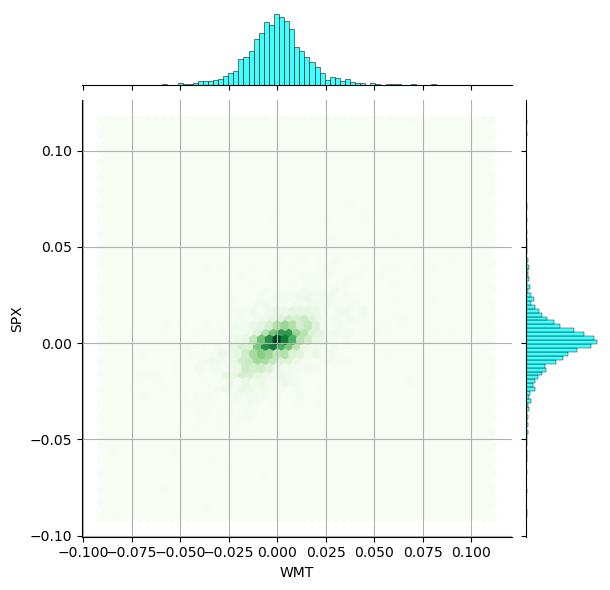

In [102]:
sns.jointplot(x = "WMT" , y = "SPX", data = ret, kind = "hex" , cmap="Greens" , color="cyan")

plt.grid()
plt.show()

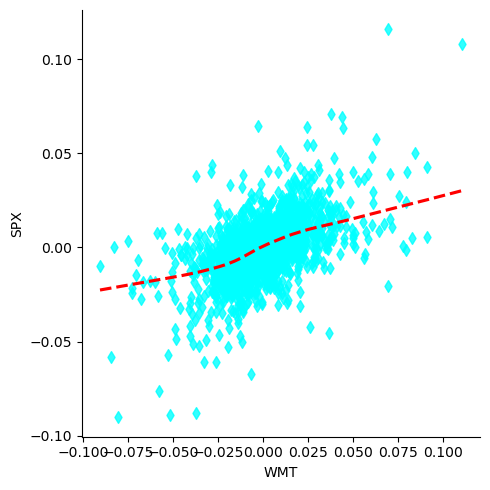

In [143]:
sns.lmplot(x = "WMT", y = "SPX", data = ret, 
           lowess = True, 
           markers = "d",
           line_kws = {"color":"red" , "ls":"--"} , 
           scatter_kws = {"color":"cyan"},
           ci = 95 
        )
sns.despine()

11. Create and fit the __ols model__. Return and interpret the __Summary Table__.

In [140]:
model_market = ols("SPX ~ WMT", data = ret)
results_market = model_market.fit()
print(results_market.summary())

                            OLS Regression Results                            
Dep. Variable:                    SPX   R-squared:                       0.300
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     1076.
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          8.51e-197
Time:                        13:48:53   Log-Likelihood:                 7612.5
No. Observations:                2514   AIC:                        -1.522e+04
Df Residuals:                    2512   BIC:                        -1.521e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.672e-05      0.000      0.072      0.9

# Well Done!

---------------------------------------------------------------------------------------------------------------------